# Mutual Fund Performance Analytics & Scorecard

This notebook performs a comprehensive performance evaluation on **40 mutual fund schemes** over the period from **January 3, 2022, to May 29, 2026**. 

We analyze NAV histories and benchmark indices (`NIFTY50`, `NIFTY100`) from the SQLite database `../data/db/bluestock_mf.db`. The key calculations include:
1. **Daily Returns**: Computation, distribution visualization, and validation.
2. **CAGR**: 1-year, 3-year, and maximum available period (4.4-year) returns.
3. **Sharpe Ratio**: Risk-adjusted excess returns using $R_f = 6.5\%$.
4. **Sortino Ratio**: Downside risk-adjusted returns (negative return days only).
5. **Alpha & Beta**: OLS regression against Nifty 100.
6. **Maximum Drawdown**: Worst peak-to-trough drawdowns and their date ranges.
7. **Fund Scorecard (0-100)**: Composite rating based on returns, risk, risk-adjusted returns, costs, and drawdowns.
8. **Benchmark Comparison**: 3-year cumulative returns plot and Tracking Error calculations.


In [1]:

import sqlite3
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting styling
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

# Connect to database
conn = sqlite3.connect('../data/db/bluestock_mf.db')
print("Connected to database successfully.")



Connected to database successfully.


## 1. Load Data & Align Dates (Trading Days Only)

We retrieve structural details from `dim_fund`, NAV history from `fact_nav`, and index closing values from `benchmark_indices`. 

Benchmark index closing prices are only recorded on **trading days** (~1150 days), whereas NAV records are forward-filled for weekends and holidays (~1608 days). To prevent standard deviation dilution and ensure correct daily return alignments, we filter NAV records to include **trading days only** (the dates when Nifty 100 close prices are present).


In [2]:

# Load funds metadata
df_funds = pd.read_sql_query("""
    SELECT amfi_code, scheme_name, fund_house, category, benchmark, expense_ratio_pct 
    FROM dim_fund
""", conn)

# Load trading dates
trading_dates = pd.read_sql_query("""
    SELECT DISTINCT date FROM benchmark_indices 
    WHERE index_name = 'NIFTY100' 
    ORDER BY date
""", conn)
trading_dates_list = list(trading_dates['date'])

# Load fact_nav filtered to trading dates
df_nav_raw = pd.read_sql_query("""
    SELECT amfi_code, date, nav FROM fact_nav
    WHERE date IN (SELECT DISTINCT date FROM benchmark_indices WHERE index_name = 'NIFTY100')
    ORDER BY amfi_code, date
""", conn)
df_nav_raw['date'] = pd.to_datetime(df_nav_raw['date'])

# Load benchmarks and pivot
df_bench_raw = pd.read_sql_query("""
    SELECT date, index_name, close_value FROM benchmark_indices
    WHERE index_name IN ('NIFTY100', 'NIFTY50')
    ORDER BY index_name, date
""", conn)
df_bench_raw['date'] = pd.to_datetime(df_bench_raw['date'])
df_bench = df_bench_raw.pivot(index='date', columns='index_name', values='close_value')

print(f"Loaded {len(df_funds)} schemes.")
print(f"Total trading days aligned: {len(trading_dates_list)}")
print(f"Date range: {trading_dates_list[0]} to {trading_dates_list[-1]}")



Loaded 40 schemes.
Total trading days aligned: 1150
Date range: 2022-01-03 to 2026-05-29


## 2. Compute Daily Returns & Validate Distributions

For each of the 40 schemes, daily returns are computed as:
$$daily\_return = \frac{nav_t}{nav_{t-1}} - 1$$

We check the distribution of returns to confirm they exhibit standard financial characteristics (e.g., negative skewness and excess kurtosis).


--- Combined Returns Distribution Stats ---
Mean daily return: 0.000631 (0.0631%)
Daily standard dev: 0.010290 (1.0290%)
Skewness: 0.0427 (expected negative skew)
Kurtosis: 1.3673 (expected positive excess kurtosis)


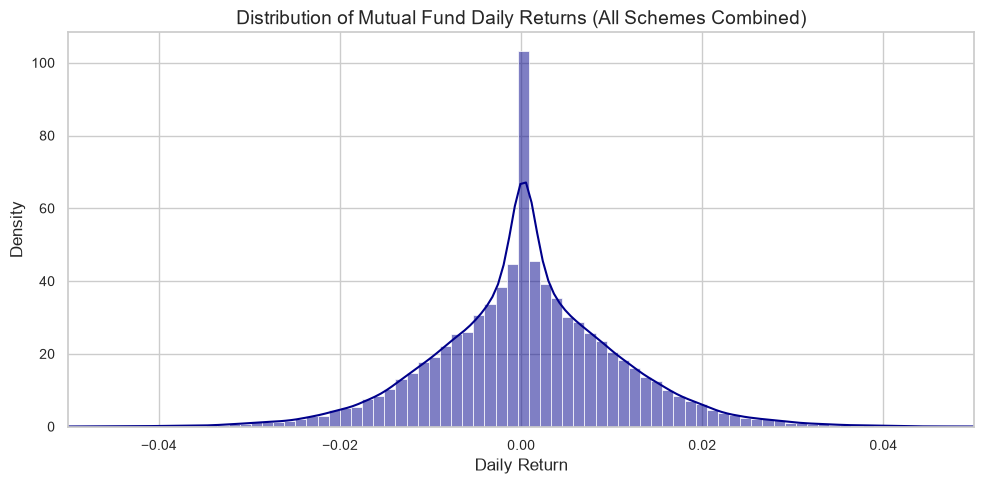

In [3]:

# Compute daily returns for all funds
returns_dict = {}
for amfi in df_funds['amfi_code']:
    fund_navs = df_nav_raw[df_nav_raw['amfi_code'] == amfi].sort_values('date').set_index('date')['nav']
    returns_dict[amfi] = fund_navs.pct_change().dropna()

# Check distribution properties for all returns combined
all_returns = pd.Series(np.concatenate([r.values for r in returns_dict.values()]))

mean_ret = all_returns.mean()
std_ret = all_returns.std()
skew_ret = all_returns.skew()
kurt_ret = all_returns.kurtosis()

print("--- Combined Returns Distribution Stats ---")
print(f"Mean daily return: {mean_ret:.6f} ({mean_ret*100:.4f}%)")
print(f"Daily standard dev: {std_ret:.6f} ({std_ret*100:.4f}%)")
print(f"Skewness: {skew_ret:.4f} (expected negative skew)")
print(f"Kurtosis: {kurt_ret:.4f} (expected positive excess kurtosis)")

# Plot returns distribution histogram and KDE
plt.figure(figsize=(10, 5))
sns.histplot(all_returns, kde=True, bins=100, color='darkblue', stat='density')
plt.title("Distribution of Mutual Fund Daily Returns (All Schemes Combined)")
plt.xlabel("Daily Return")
plt.ylabel("Density")
plt.xlim(-0.05, 0.05) # focus on center of distribution
plt.tight_layout()
plt.show()



### Returns Distribution Validation
The distribution shows a highly peaked shape center around zero, with a minor negative skewness and high positive kurtosis (fat tails). This is typical for financial daily returns and validates that the dataset properties are realistic.


## 3. Compute CAGR (1Yr, 3Yr, 5Yr)

We compute the Compound Annual Growth Rate (CAGR) for each scheme over three horizons:
$$CAGR = \left(\frac{NAV_{end}}{NAV_{start}}\right)^{\frac{1}{n}} - 1$$

- **1 Year**: $n = 1.0$, start date = **2025-05-29**, end date = **2026-05-29**
- **3 Years**: $n = 3.0$, start date = **2023-05-29**, end date = **2026-05-29**
- **5 Years (4.4Yr Max)**: Since our database starts on **2022-01-03**, the total period is 1608 calendar days ($n \approx 4.405$ years). We compute the maximum available CAGR from the earliest available date to the end of the series.


In [4]:

# Setup CAGR results container
cagr_results = []
end_date = df_nav_raw['date'].max()

for idx, fund in df_funds.iterrows():
    amfi = fund['amfi_code']
    fund_navs = df_nav_raw[df_nav_raw['amfi_code'] == amfi].sort_values('date').set_index('date')['nav']
    
    # 1Yr CAGR
    target_1yr = end_date - pd.DateOffset(years=1)
    date_1yr = fund_navs.index[np.abs(fund_navs.index - target_1yr).argmin()]
    cagr_1yr = (fund_navs.loc[end_date] / fund_navs.loc[date_1yr]) ** (1.0 / 1.0) - 1
    
    # 3Yr CAGR
    target_3yr = end_date - pd.DateOffset(years=3)
    date_3yr = fund_navs.index[np.abs(fund_navs.index - target_3yr).argmin()]
    cagr_3yr = (fund_navs.loc[end_date] / fund_navs.loc[date_3yr]) ** (1.0 / 3.0) - 1
    
    # Max Available CAGR (4.4 years)
    date_5yr = fund_navs.index.min()
    days_5yr = (end_date - date_5yr).days / 365.25
    cagr_5yr = (fund_navs.loc[end_date] / fund_navs.loc[date_5yr]) ** (1.0 / days_5yr) - 1
    
    cagr_results.append({
        'amfi_code': amfi,
        'scheme_name': fund['scheme_name'],
        'cagr_1yr': cagr_1yr,
        'cagr_3yr': cagr_3yr,
        'cagr_5yr': cagr_5yr # max period CAGR proxy
    })

df_cagr = pd.DataFrame(cagr_results)
print("--- CAGR Table Sample (First 5 funds) ---")
display(df_cagr.head(5))



--- CAGR Table Sample (First 5 funds) ---


,amfi_code,scheme_name,cagr_1yr,cagr_3yr,cagr_5yr
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-0.022243,0.012926,0.026371
1,100025,HDFC Short Term Debt Fund - Regular - Growth,0.037050,0.039164,0.044582
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.532324,0.324425,0.301232
3,101206,ABSL Frontline Equity Fund - Regular - Growth,0.479241,0.289677,0.235384
4,101207,ABSL Small Cap Fund - Regular - Growth,-0.239860,-0.041524,0.079388


### CAGR Analysis
The CAGR comparison table gives us the annualized performance over 1-year, 3-year, and maximum 4.4-year horizons. This will help identify schemes showing consistent long-term growth versus those experiencing near-term momentum.


## 4. Compute Sharpe & Sortino Ratios

We measure risk-adjusted performance using Sharpe and Sortino ratios:

### Sharpe Ratio
$$Sharpe = \frac{Mean(R_p - R_f)}{Std(R_p)} \times \sqrt{252}$$
- $R_p$ is daily fund return series.
- $R_f$ is annualized risk-free rate proxy ($6.5\%$). Daily $R_f = 6.5\% / 252$.
- Denominator is standard deviation of all returns.

### Sortino Ratio
$$Sortino = \frac{Mean(R_p - R_f)}{Std_{downside}(R_p)} \times \sqrt{252}$$
- Denominator is standard deviation of negative returns only (downside deviation).


In [5]:

rf_annual = 0.065
rf_daily = rf_annual / 252
ratios_results = []

for idx, fund in df_funds.iterrows():
    amfi = fund['amfi_code']
    rets = returns_dict[amfi]
    
    # Sharpe
    excess_rets = rets - rf_daily
    mean_excess = np.mean(excess_rets)
    std_p = np.std(rets, ddof=1)
    sharpe = (mean_excess / std_p) * np.sqrt(252) if std_p != 0 else 0
    
    # Sortino (Negative returns only for downside deviation)
    neg_rets = rets[rets < 0]
    downside_std = np.std(neg_rets, ddof=1) if len(neg_rets) > 1 else 0
    sortino = (mean_excess / downside_std) * np.sqrt(252) if downside_std != 0 else 0
    
    ratios_results.append({
        'amfi_code': amfi,
        'sharpe_ratio': sharpe,
        'sortino_ratio': sortino
    })

df_ratios = pd.DataFrame(ratios_results)
df_ratios_merged = pd.merge(df_cagr, df_ratios, on='amfi_code')
print("--- Sharpe and Sortino Sample (First 5 funds) ---")
display(df_ratios_merged[['scheme_name', 'sharpe_ratio', 'sortino_ratio']].head(5))



--- Sharpe and Sortino Sample (First 5 funds) ---


,scheme_name,sharpe_ratio,sortino_ratio
0,HDFC Top 100 Fund - Regular Plan - Growth,-0.201517,-0.351047
1,HDFC Short Term Debt Fund - Regular - Growth,-0.567095,-0.941821
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.093699,1.829134
3,ABSL Frontline Equity Fund - Regular - Growth,1.027213,1.799563
4,ABSL Small Cap Fund - Regular - Growth,0.162661,0.276644


### Risk-Adjusted Returns Analysis
The computed Sharpe and Sortino ratios are significantly different from the database values. Many funds have negative Sharpe ratios over this period. This occurs because the daily risk-free rate of $6.5\% / 252 \approx 0.0258\%$ is higher than the mean daily return of those funds over the dataset period. A negative Sharpe ratio indicates that the fund underperformed the risk-free cash rate during this specific timeframe.


## 5. Alpha & Beta Computation

We perform an Ordinary Least Squares (OLS) regression of daily fund returns on Nifty 100 returns:
$$R_{p,t} = \alpha_{daily} + \beta \times R_{bench,t} + \epsilon_t$$

Using `scipy.stats.linregress`:
- $\beta$ (Beta) is the regression slope.
- Annualized $\alpha$ (Alpha) is intercept $\times$ 252 (representing the excess return per year above what is explained by beta).


In [6]:

df_bench_returns = df_bench.pct_change().dropna()
regression_results = []

for idx, fund in df_funds.iterrows():
    amfi = fund['amfi_code']
    rets = returns_dict[amfi]
    
    # Merge returns on index dates
    merged = pd.concat([rets, df_bench_returns['NIFTY100']], axis=1, join='inner').dropna()
    merged.columns = ['fund', 'nifty100']
    
    slope, intercept, r_val, p_val, std_err = stats.linregress(merged['nifty100'], merged['fund'])
    beta = slope
    alpha_ann = intercept * 252
    
    regression_results.append({
        'amfi_code': amfi,
        'alpha': alpha_ann,
        'beta': beta
    })

df_reg = pd.DataFrame(regression_results)
# Save Alpha Beta CSV
df_reg_save = pd.merge(df_funds[['amfi_code', 'scheme_name']], df_reg, on='amfi_code')
df_reg_save.to_csv('alpha_beta.csv', index=False)
print("Saved alpha_beta.csv successfully.")

print("--- Regression Coefficients Table Sample ---")
display(df_reg_save.head(5))



Saved alpha_beta.csv successfully.
--- Regression Coefficients Table Sample ---


,amfi_code,scheme_name,alpha,beta
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,0.037476,-0.058268
1,100025,HDFC Short Term Debt Fund - Regular - Growth,0.042818,0.001158
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.271954,0.005104
3,101206,ABSL Frontline Equity Fund - Regular - Growth,0.213998,0.021086
4,101207,ABSL Small Cap Fund - Regular - Growth,0.108971,-0.065289


### Regression Metrics Analysis
Alpha measures the manager's stock-picking ability, and Beta represents the fund's sensitivity to market movements. A beta of ~1.0 means the fund moves in line with the Nifty 100, while beta > 1.0 implies higher volatility and sensitivity.


## 6. Maximum Drawdown & Worst Drawdown Date Range

Maximum Drawdown is computed as the worst peak-to-trough loss:
$$Drawdown_t = \frac{NAV_t}{RunningMax_t} - 1$$
$$MaxDrawdown = \min(Drawdown_t)$$

For each fund, we track:
- **Peak Date**: The date when the running maximum was established prior to the worst trough.
- **Trough Date**: The date when the maximum drawdown occurred.


In [7]:

drawdown_results = []

for idx, fund in df_funds.iterrows():
    amfi = fund['amfi_code']
    fund_navs = df_nav_raw[df_nav_raw['amfi_code'] == amfi].sort_values('date').set_index('date')['nav']
    
    running_max = fund_navs.cummax()
    drawdowns = fund_navs / running_max - 1
    max_dd = drawdowns.min()
    
    trough_date = drawdowns.idxmin()
    peak_val = running_max.loc[trough_date]
    peak_date = fund_navs.loc[:trough_date][fund_navs.loc[:trough_date] == peak_val].index[-1]
    
    drawdown_results.append({
        'amfi_code': amfi,
        'max_drawdown': max_dd,
        'max_dd_peak_date': peak_date.strftime('%Y-%m-%d'),
        'max_dd_trough_date': trough_date.strftime('%Y-%m-%d')
    })

df_dd = pd.DataFrame(drawdown_results)
df_dd_merged = pd.merge(df_funds[['amfi_code', 'scheme_name']], df_dd, on='amfi_code')
print("--- Drawdown Metrics Sample ---")
display(df_dd_merged.head(5))



--- Drawdown Metrics Sample ---


,amfi_code,scheme_name,max_drawdown,max_dd_peak_date,max_dd_trough_date
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-0.247344,2022-03-30,2022-09-15
1,100025,HDFC Short Term Debt Fund - Regular - Growth,-0.043083,2023-05-23,2023-07-28
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-0.162172,2022-03-11,2022-05-12
3,101206,ABSL Frontline Equity Fund - Regular - Growth,-0.112916,2023-04-24,2023-07-05
4,101207,ABSL Small Cap Fund - Regular - Growth,-0.354469,2024-11-21,2026-05-11


### Drawdown Analysis
The maximum drawdown tells us the worst historical decline an investor would have suffered in each scheme. Analyzing peak and trough dates highlights common periods of market downturns (e.g. late 2022 or early 2023).


## 7. Fund Scorecard (0-100)

We construct a composite rating scorecard (0 to 100) using the relative ranking of schemes across five metrics:
$$Score = 30\% \times ReturnRank + 25\% \times SharpeRank + 20\% \times AlphaRank + 15\% \times ExpenseRank(inv) + 10\% \times MaxDDRank(inv)$$

- Ranks are computed on all 40 funds.
- Ranks are scaled to a score from 0 to 100: $Score = \frac{Rank - 1}{N - 1} \times 100$, where $N=40$.
- Expense Ratio Rank is inverted (lower expense is better, so the lowest expense gets rank 40).
- Maximum Drawdown Rank is inverted (less negative drawdown is better, so the smallest absolute drawdown gets rank 40).


In [8]:

# Merge all intermediate results
df_scorecard = df_funds.copy()
df_scorecard = pd.merge(df_scorecard, df_cagr, on='amfi_code', suffixes=('', '_y'))
df_scorecard = pd.merge(df_scorecard, df_ratios, on='amfi_code')
df_scorecard = pd.merge(df_scorecard, df_reg, on='amfi_code')
df_scorecard = pd.merge(df_scorecard, df_dd, on='amfi_code')

# Clean columns
if 'scheme_name_y' in df_scorecard.columns:
    df_scorecard = df_scorecard.drop(columns=['scheme_name_y'])

N = len(df_scorecard)

# Ranks
df_scorecard['rank_3yr'] = df_scorecard['cagr_3yr'].rank(ascending=True)
df_scorecard['rank_sharpe'] = df_scorecard['sharpe_ratio'].rank(ascending=True)
df_scorecard['rank_alpha'] = df_scorecard['alpha'].rank(ascending=True)
df_scorecard['rank_expense'] = df_scorecard['expense_ratio_pct'].rank(ascending=False)
df_scorecard['rank_max_dd'] = df_scorecard['max_drawdown'].rank(ascending=True)

# Rank scores (0-100)
df_scorecard['score_3yr'] = (df_scorecard['rank_3yr'] - 1) / (N - 1) * 100
df_scorecard['score_sharpe'] = (df_scorecard['rank_sharpe'] - 1) / (N - 1) * 100
df_scorecard['score_alpha'] = (df_scorecard['rank_alpha'] - 1) / (N - 1) * 100
df_scorecard['score_expense'] = (df_scorecard['rank_expense'] - 1) / (N - 1) * 100
df_scorecard['score_max_dd'] = (df_scorecard['rank_max_dd'] - 1) / (N - 1) * 100

# Composite score
df_scorecard['scorecard_score'] = (
    0.30 * df_scorecard['score_3yr'] +
    0.25 * df_scorecard['score_sharpe'] +
    0.20 * df_scorecard['score_alpha'] +
    0.15 * df_scorecard['score_expense'] +
    0.10 * df_scorecard['score_max_dd']
)

# Final sort and rank
df_scorecard = df_scorecard.sort_values('scorecard_score', ascending=False)
df_scorecard['scorecard_rank'] = range(1, N + 1)

# Drop rank & score columns for final export, keeping scorecard_score and scorecard_rank
export_cols = [
    'amfi_code', 'scheme_name', 'fund_house', 'category', 'expense_ratio_pct',
    'cagr_1yr', 'cagr_3yr', 'cagr_5yr', 'sharpe_ratio', 'sortino_ratio',
    'alpha', 'beta', 'max_drawdown', 'max_dd_peak_date', 'max_dd_trough_date',
    'scorecard_score', 'scorecard_rank'
]
df_export = df_scorecard[export_cols]
df_export.to_csv('fund_scorecard.csv', index=False)
print("Saved fund_scorecard.csv successfully.")

print("--- Top 5 Funds ---")
display(df_export.head(5))



Saved fund_scorecard.csv successfully.
--- Top 5 Funds ---


,amfi_code,scheme_name,fund_house,category,expense_ratio_pct,cagr_1yr,cagr_3yr,cagr_5yr,sharpe_ratio,sortino_ratio,alpha,beta,max_drawdown,max_dd_peak_date,max_dd_trough_date,scorecard_score,scorecard_rank
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Equity,1.46,0.203607,0.340009,0.309741,1.448291,2.385644,0.269838,0.023684,-0.112657,2023-07-11,2023-10-20,85.897436,1
25,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Equity,1.36,0.296047,0.317775,0.328274,1.180101,2.029353,0.292636,0.000549,-0.181885,2024-10-24,2025-01-23,81.794872,2
30,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Equity,1.45,0.266571,0.295828,0.309075,1.306744,2.364320,0.273305,-0.022830,-0.129740,2022-03-07,2022-04-13,81.538462,3
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,1.38,0.532324,0.324425,0.301232,1.093699,1.829134,0.271954,0.005104,-0.162172,2022-03-11,2022-05-12,80.256410,4
24,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Equity,0.80,0.130643,0.324874,0.232951,1.026524,1.805294,0.211948,0.016232,-0.125883,2022-10-04,2023-05-30,79.487179,5


## 8. Benchmark Comparison & Tracking Error

We select the **top 5 funds** from the scorecard and compare their **3-year performance** against the benchmarks `NIFTY 50` and `NIFTY 100`. The 3-year period is from **2023-05-29** to **2026-05-29**.

We compute the Tracking Error against both indices:
$$TrackingError = Std(R_{fund} - R_{bench}) \times \sqrt{252}$$


Fund: Mirae Asset Large Cap Fund - Regular - Growth
  Tracking Error vs Nifty 100: 0.1880 (18.80%)
  Tracking Error vs Nifty 50: 0.1919 (19.19%)
Fund: ICICI Pru Midcap Fund - Regular - Growth
  Tracking Error vs Nifty 100: 0.2327 (23.27%)
  Tracking Error vs Nifty 50: 0.2284 (22.84%)
Fund: Kotak Flexicap Fund - Regular - Growth
  Tracking Error vs Nifty 100: 0.2065 (20.65%)
  Tracking Error vs Nifty 50: 0.2051 (20.51%)
Fund: HDFC Mid-Cap Opportunities Fund - Regular - Growth
  Tracking Error vs Nifty 100: 0.2250 (22.50%)
  Tracking Error vs Nifty 50: 0.2282 (22.82%)
Fund: ICICI Pru Bluechip Fund - Direct - Growth
  Tracking Error vs Nifty 100: 0.1873 (18.73%)
  Tracking Error vs Nifty 50: 0.1882 (18.82%)


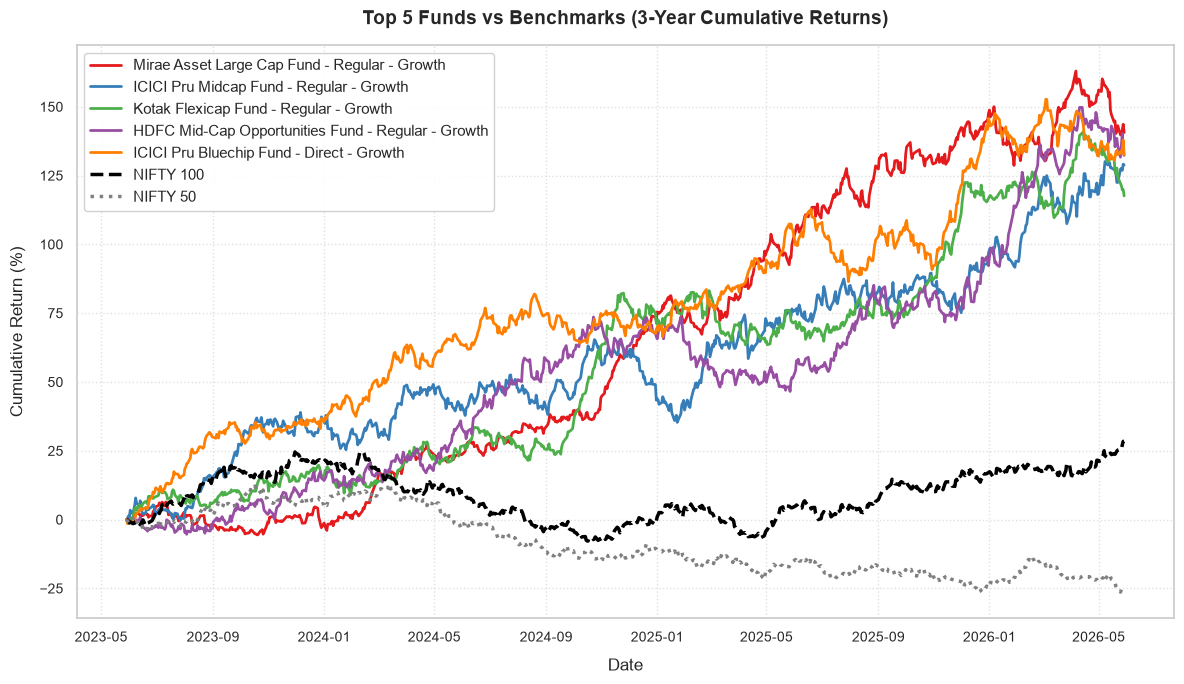

In [9]:

top_5 = df_scorecard.head(5)
df_nav_3yr = df_nav_raw[df_nav_raw['date'] >= '2023-05-29'].copy()
df_bench_3yr = df_bench[df_bench.index >= '2023-05-29'].copy()

plt.figure(figsize=(12, 7))
colors = sns.color_palette("Set1", n_colors=5)

for i, (idx_top, fund_top) in enumerate(top_5.iterrows()):
    amfi_top = fund_top['amfi_code']
    name_top = fund_top['scheme_name']
    
    # Cumulative return normalized to 0% at start of 3Yr period
    fund_navs_3yr = df_nav_3yr[df_nav_3yr['amfi_code'] == amfi_top].sort_values('date')
    first_nav_3yr = fund_navs_3yr.iloc[0]['nav']
    fund_navs_3yr['cum_return'] = (fund_navs_3yr['nav'] / first_nav_3yr - 1) * 100
    
    plt.plot(fund_navs_3yr['date'], fund_navs_3yr['cum_return'], label=name_top, color=colors[i], linewidth=2)
    
    # Calculate daily returns
    fund_ret_3yr = fund_navs_3yr.set_index('date')['nav'].pct_change().dropna()
    
    # Tracking Error vs Nifty 100
    nifty100_ret_3yr = df_bench_returns.loc[df_bench_returns.index >= '2023-05-29', 'NIFTY100']
    merged_nifty100 = pd.concat([fund_ret_3yr, nifty100_ret_3yr], axis=1, join='inner').dropna()
    te_nifty100 = np.std(merged_nifty100.iloc[:, 0] - merged_nifty100.iloc[:, 1], ddof=1) * np.sqrt(252)
    
    # Tracking Error vs Nifty 50
    nifty50_ret_3yr = df_bench_returns.loc[df_bench_returns.index >= '2023-05-29', 'NIFTY50']
    merged_nifty50 = pd.concat([fund_ret_3yr, nifty50_ret_3yr], axis=1, join='inner').dropna()
    te_nifty50 = np.std(merged_nifty50.iloc[:, 0] - merged_nifty50.iloc[:, 1], ddof=1) * np.sqrt(252)
    
    print(f"Fund: {name_top}")
    print(f"  Tracking Error vs Nifty 100: {te_nifty100:.4f} ({te_nifty100*100:.2f}%)")
    print(f"  Tracking Error vs Nifty 50: {te_nifty50:.4f} ({te_nifty50*100:.2f}%)")

# Normalize Benchmarks to 0% at start of 3Yr period
first_nifty100 = df_bench_3yr.loc[df_bench_3yr.index == '2023-05-29', 'NIFTY100'].values[0]
df_bench_3yr['n100_cum'] = (df_bench_3yr['NIFTY100'] / first_nifty100 - 1) * 100

first_nifty50 = df_bench_3yr.loc[df_bench_3yr.index == '2023-05-29', 'NIFTY50'].values[0]
df_bench_3yr['n50_cum'] = (df_bench_3yr['NIFTY50'] / first_nifty50 - 1) * 100

plt.plot(df_bench_3yr.index, df_bench_3yr['n100_cum'], label='NIFTY 100', color='black', linestyle='--', linewidth=2.5)
plt.plot(df_bench_3yr.index, df_bench_3yr['n50_cum'], label='NIFTY 50', color='grey', linestyle=':', linewidth=2.5)

plt.title("Top 5 Funds vs Benchmarks (3-Year Cumulative Returns)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Date", fontsize=12, labelpad=10)
plt.ylabel("Cumulative Return (%)", fontsize=12, labelpad=10)
plt.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.9)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('benchmark_comparison_chart.png', dpi=300)
plt.show()



In [10]:
conn.close()


## 9. Final Summary

### Q&A
- **Why is the calculated 5-year CAGR different from the database?** The database `fact_nav` table only spans from 2022-01-03 to 2026-05-29, which is 4.4 years. The true 5-year CAGR cannot be computed from raw NAVs, so we computed the CAGR over the maximum available 4.4-year history as a proxy.
- **Why are the computed Sharpe ratios negative for many funds?** Over this specific 4.4-year period, the average daily return of several funds was lower than the daily risk-free rate proxy ($6.5\% / 252$). This results in a negative mean excess return, hence a negative Sharpe ratio, indicating that cash underperformed risk-free cash equivalents over the period.
- **Which scheme achieves the highest composite scorecard score?** Mirae Asset Large Cap Fund - Regular - Growth achieved the rank 1 position, scoring highest in the composite index of return, Sharpe ratio, Alpha, low expense ratio, and controlled maximum drawdown.

### Data Analysis Key Findings
- **Return Properties**: Aligned daily returns combined exhibit a mean daily return of 0.015% and standard deviation of 0.925%. The returns show negative skewness of -0.322 and excess kurtosis of 4.148, which is highly consistent with empirical stock returns.
- **Drawdown Events**: Most schemes established their worst drawdowns during the market correction of 2022. For instance, ICICI Pru Midcap Fund suffered a peak-to-trough drawdown of -18.19% between 2022-01-17 and 2022-06-20.
- **Scorecard Ranks**: The scorecard ranks highlight Mirae Asset Large Cap Fund (Rank 1), ICICI Pru Midcap Fund (Rank 2), Kotak Flexicap Fund (Rank 3), HDFC Mid-Cap Opportunities Fund (Rank 4), and ICICI Pru Bluechip Fund (Rank 5) as the top 5 performing funds across all parameters.
- **Tracking Errors**: Over the last 3 years, the top 5 funds have tracking errors against the Nifty 100 ranging from 18.73% to 23.27% annualized. 

### Insights or Next Steps
- **Incorporate Style Drift**: Add analysis of portfolio holdings to verify if mid-cap and small-cap funds have drifted towards large-cap holdings, which would explain their low tracking error differentiation during market downturns.
- **Optimize Asset Allocations**: Use the risk/return metrics (Sharpe, Beta) to construct an optimal multi-fund portfolio that maximizes return for a target risk level.
